# Import

In [1]:
import parcels
from parcels import FieldSet, JITParticle, ParticleSet, NestedField

import datetime as dt
from datetime import datetime, timedelta

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
from pandas import timedelta_range as td_range

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cmocean

import xarray as xr
from glob import glob
from cartopy.crs import Geodetic, PlateCarree
from time import time
import warnings
from shapely import Polygon
from itertools import chain

warnings.simplefilter("ignore")

# Set Parameters

In [ ]:
# Parameters
# Don't Change these
RNG_seed = 123
show_verbose_progress = False
is_papermill = False

# Base path for project data (varies per user)
base_path = "/gxfs_work/geomar/smomw597/2025_Fucus"

# Chose Release timeframe
release_year = 2019
first_release_month = 1
first_release_day = 1

last_release_month = 1
last_release_day = 29

# Chose timestep in minutes
calc_dt_mins = 15
output_dt_mins = 60

# Is it supposed to be a repeated release?
repeated_release = False
# If so, how many days between the releases
repeated_release_dt_days = 7

# What is the maximum age of the particles
max_age_days = 50

# At what realtive depth should the particles be released? (0=surface, 1=sea floor)
relative_release_depth = 0
# Relative speed of the paricles
relative_particle_speed = 1
# How many particles should be released each time per release cell?
particles_per_cell = 1000

In [43]:
# Be sure to not have a loading bar, when done with Papermill
if not is_papermill: show_verbose_progress = True

# Time Parameters

In [44]:
# Get time variables from parameters
first_release_date = datetime(release_year, first_release_month, first_release_day)
end_release_timeframe = datetime(release_year, last_release_month, last_release_day)

repeat_dt = timedelta(days=repeated_release_dt_days)
calc_dt = timedelta(minutes=calc_dt_mins)
output_dt = timedelta(minutes=output_dt_mins)

# Generate all release dates
release_dates = [first_release_date + release_dt 
        for release_dt in td_range(0, periods=100, freq=repeat_dt)
        if first_release_date + release_dt < end_release_timeframe
]
if not repeated_release: # If no repeated release, set release dates to first release
        release_dates = [first_release_date]
# Get remaining time variables
last_release_date = release_dates[-1]
last_modeling_date = last_release_date + timedelta(days=max_age_days)# + timedelta(days=1)
last_loaded_date = last_modeling_date + timedelta(days=1)
print(
        "first release date:", first_release_date.date(),
        "\nlast release date:", last_release_date.date(),
        "\nlast date in release timeframe:", end_release_timeframe.date(),
        "\nlast modeling date:", last_modeling_date.date(),
        "\nlast loaded date:", last_loaded_date.date(),
)

first release date: 2019-01-01 
last release date: 2019-01-01 
last date in release timeframe: 2019-01-29 
last modeling date: 2019-02-20 
last loaded date: 2019-02-21


In [ ]:
# Set random seed
np.random.seed(RNG_seed)
years = range(first_release_date.year, last_modeling_date.year + 1)
# Get the important dates as strings for file name and filter
first_release_date_str = first_release_date.strftime("%Y%m%d")
last_release_date_str = last_release_date.strftime("%Y%m%d")
last_loaded_date_str = last_loaded_date.strftime("%Y%m%d")

## Set Path Variables

In [ ]:
# establish folder paths
base_path = Path(base_path)
repo_path = Path(base_path, "2025_fucus-dispersal")
save_path = Path(base_path, "output/Trajectories/", str(release_year))
path_orig_files = Path("/gxfs_work/geomar/smomw400/bsh_operationalmodel_data")
path_sigma_files = Path(base_path, "output/sigma")
path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
path_static_fine = Path(path_static_files, "static_file_fine")
path_static_coarse = Path(path_static_files, "static_file_coarse")

# get static file paths
lonlat_file_fine = Path(path_static_fine, "lonlat_file_fine.nc")
lonlat_file_coarse = Path(path_static_coarse, "lonlat_file_coarse.nc")

sigma_file_fine = Path(path_sigma_files, "sigma_fine.nc")
sigma_file_coarse = Path(path_sigma_files, "sigma_coarse.nc")

In [47]:
# Get all the subfolders for the requested years
current_subfolder_fine = list(map(lambda year: "c_file_fine_" + str(year), years))
current_subfolder_coarse = list(map(lambda year: "c_file_coarse_" + str(year), years))
salt_temp_subfolder_fine = list(map(lambda year: "t_file_fine_" + str(year), years))
salt_temp_subfolder_coarse = list(map(lambda year: "t_file_coarse_" + str(year), years))

In [48]:
# Get filenames from the subfolder while filtering them for the timeframe 
def get_file_list(subfolder_list: list, path: Path):
        files_list = list(
                chain.from_iterable(
                        sorted(path.glob(f"{subfolder}/*")) 
                        for subfolder in subfolder_list))
        # Get the position of the date in the file name 
        a = files_list[0].name.find(str(release_year))
        b = a + 8
        # filter list for dates, between the start and end of the timeframe
        return list(filter(
                lambda x: first_release_date_str <= x.name[a:b] <= last_loaded_date_str,
                files_list
        ))

In [49]:
def get_timestamp_from_file(fname):
        YYYYMMDDHH = fname.name.split("_")[3]
        y = YYYYMMDDHH[:4]
        m = YYYYMMDDHH[4:6]
        d = YYYYMMDDHH[6:8]
        h = YYYYMMDDHH[-2:]
        t0 = np.datetime64(f"{y}-{m}-{d}T{h}:15:00")
        return list(t0 + np.arange(4 * 6) * np.timedelta64(15 * 60, "s"))

In [50]:
# get file list paths
current_files_fine = get_file_list(current_subfolder_fine, path_orig_files)
current_files_coarse = get_file_list(current_subfolder_coarse, path_orig_files)

salt_temp_files_fine = get_file_list(salt_temp_subfolder_fine, path_orig_files)
salt_temp_files_coarse = get_file_list(salt_temp_subfolder_coarse, path_orig_files)
print(
        "Number of files per list:", len(current_files_coarse),
        "\nlast loaded file:", current_files_coarse[-1].name,
)

Number of files per list: 208 
last loaded file: c_file_coarse_2019022118_000_006.nc


In [51]:
timestamps = [get_timestamp_from_file(cf) for cf in current_files_fine]

# Construct release locations

In [ ]:
# Read the release area file
release_area_path = Path(repo_path, "data/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
# release_area_path = Path(repo_path, "output/SamplePoints")
# gdf_release_area = gpd.read_file(Path(release_area_path, "sh_baltic_coast_release_areas.geojson"))
# Filter release area file for locations where Fucus was found and remove irrelevant columns
gdf_release_area = gdf_release_area.loc[
        (gdf_release_area.F_vesiculo != 0).values, 
        ["F_vesiculo", "geometry", "CELLID"],
].to_crs(crs=Geodetic()) # Make sure, it is in the right projection

# if not is_papermill: gdf_release_area = gdf_release_area[:25]
        
# Get total number of particles
n_releases = len(release_dates)
n_release_cells = len(gdf_release_area)
n_particles_per_release = particles_per_cell * n_release_cells
n_total_particles = n_releases * particles_per_cell * n_release_cells 
# Construct an array with the realease times
release_times = tuple(
        np.concatenate(
                np.transpose([release_dates] * n_particles_per_release)
        ) + timedelta(hours=6)
)

print(
        "total number of particles:", n_total_particles, 
        "\nnumber of release cells:", len(gdf_release_area),
        "\nlast release time:", release_times[-1],
)

In [54]:
def relative_position_in_cell(x_rel: float, y_rel: float, cell: Polygon):
        (x0, y0), (x1, y1), (x2, y2), (x3, y3), (x4, y4) = cell.exterior.coords
        ex = (x3-x0, y3-y0)
        ey = (x1-x0, y1-y0)
        return x0 + x_rel * ex[0] + y_rel * ey[0], y0 + x_rel * ex[1] + y_rel * ey[1]

In [55]:
# pick a random cell and a random position within cell
release_lons, release_lats, cell_IDs = list(zip(*[
        relative_position_in_cell(rand_x, rand_y, gdf_release_area.iloc[rand_cell].geometry)
        + (gdf_release_area.iloc[rand_cell].CELLID,)
        for rand_x, rand_y, rand_cell in zip(
                uniform(size=n_total_particles),
                uniform(size=n_total_particles),
                randint(0, n_release_cells, size=n_total_particles),
        )
]))
# Construct the release depths in the same size as the release locations
release_depths = tuple(np.full_like(release_lons, relative_release_depth))

# release_depths = tuple(int(n_total_particles) * relative_release_depth)
# release_lons = tuple(np.concatenate(np.array([release_lons] * 2).T))
# release_lats = tuple(np.concatenate(np.array([release_lats] * 2).T))
# cell_IDs = tuple(np.concatenate(np.array([cell_IDs] * 2).T))
print("length of array:", len(release_lons))
len(release_lons) == len(release_lats) == len(release_depths)

length of array: 47000


True

# Parcels

## Custom Kernel

In [56]:
def delete_error_particle(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [57]:
# Establish aging for particles
def aging_kernel(particle, fieldset, time):
    particle.age_sec += particle.dt
    if particle.age_sec > fieldset.max_age_sec:
        particle.delete()

In [58]:
def AdvectionRK4_2D_SIGMABSH(particle, fieldset, time):
        sigma = particle.depth
        dt = particle.dt
        lat0 = particle.lat
        lon0 = particle.lon
        time0 = time

        (u1, v1) = fieldset.UV[time0, sigma, lat0, lon0]  # horizontal velocities in deg/s
        lat1 = lat0 + v1 * 0.5 * dt
        lon1 = lon0 + u1 * 0.5 * dt
        time1 = time0 + 0.5 * dt

        (u2, v2) = fieldset.UV[time1, sigma, lat1, lon1]
        lat2 = lat0 + v2 * 0.5 * dt
        lon2 = lon0 + u2 * 0.5 * dt
        time2 = time0 + 0.5 * dt
        
        (u3, v3) = fieldset.UV[time2, sigma, lat2, lon2]
        lat3 = lat0 + v3 * dt
        lon3 = lon0 + u3 * dt
        time3 = time0 + dt

        (u4, v4) = fieldset.UV[time3, sigma, lat3, lon3]
        lon4 = lon0 + (u1 + 2 * u2 + 2 * u3 + u4) / 6 * dt
        lat4 = lat0 + (v1 + 2 * v2 + 2 * v3 + v4) / 6 * dt

        particle_dlon += (lon4 - lon0) * fieldset.relative_particle_speed
        particle_dlat += (lat4 - lat0) * fieldset.relative_particle_speed
        # particle.u = u1
        # particle.v = v1

        # particle.S = fieldset.S[time0, sigma, lat0, lon0]
        # particle.T = fieldset.T[time0, sigma, lat0, lon0]

In [59]:
custom_kernel = [
        AdvectionRK4_2D_SIGMABSH,
        aging_kernel,
        # delete_error_particle,
]

## Fieldset

In [19]:
# Function for constructing fieldsets 
def make_fieldset(
        lonlat_file_path: Path, sigma_file_path: Path,
        data_files: list, variable_ID: list,
        variable_names: list, interp_methods: list,
        timestamps:list
        ):
        data_dict = dict(
                lon=lonlat_file_path,
                lat=lonlat_file_path, 
                depth=sigma_file_path,
                data=data_files,
        )

        data_filenames = dict(zip(variable_ID, [data_dict] * len(variable_ID)))
        data_variables = dict(zip(variable_ID, variable_names))
        data_dimensions = dict(zip(variable_ID, field_dimensions))
        interp_method = dict(zip(variable_ID, interp_methods))

        return FieldSet.from_netcdf(
                timestamps=timestamps,
                filenames=data_filenames,
                variables=data_variables,
                dimensions=data_dimensions,
                interp_method=interp_method,
                allow_time_extrapolation=False,
                gridindexingtype="nemo",
        )

In [20]:
# Create dictionary with dimensions
dimension_dict = dict(lon="lon", lat="lat", time="time", depth="sigma")
field_dimensions = [dimension_dict, dimension_dict]

# Prepare reading of variables
current_variable_ID = ["U", "V"]
current_variable_names = ["uvel", "vvel"]
current_interp_methods = ["cgrid_velocity", "cgrid_velocity"]

# salt_temp_variable_ID = ["S", "T"]
# salt_temp_variable_names = ["salt", "temp"]
# salt_temp_interp_methods = ["cgrid_tracer", "cgrid_tracer"]

In [21]:
# Create the fieldsets for currents
current_fieldset_fine = make_fieldset(
        lonlat_file_path=lonlat_file_fine, 
        sigma_file_path=sigma_file_fine, 
        data_files=current_files_fine,
        variable_ID=current_variable_ID, 
        variable_names=current_variable_names, 
        interp_methods=current_interp_methods,
        timestamps=timestamps,
)

In [22]:
current_fieldset_coarse = make_fieldset(
        lonlat_file_path=lonlat_file_coarse,
        sigma_file_path=sigma_file_coarse,
        data_files=current_files_coarse,
        variable_ID=current_variable_ID, 
        variable_names=current_variable_names, 
        interp_methods=current_interp_methods,
        timestamps=timestamps,
)

In [23]:
# Create the fieldsets for salt and temperature
# salt_temp_fieldset_fine = make_fieldset(
#         lonlat_file=lonlat_file_fine, 
#         sigma_file=sigma_file_fine, 
#         data_files=salt_temp_files_fine,
#         variable_ID=salt_temp_variable_ID, 
#         variable_names=salt_temp_variable_names, 
#         interp_methods=salt_temp_interp_methods,
# )
# salt_temp_fieldset_coarse = make_fieldset(
#         lonlat_file=lonlat_file_coarse,
#         sigma_file=sigma_file_coarse,
#         data_files=salt_temp_files_coarse,
#         variable_ID=salt_temp_variable_ID, 
#         variable_names=salt_temp_variable_names, 
#         interp_methods=salt_temp_interp_methods,
# )

### Nested fieldset

In [24]:
# Build nested fieldset
U_nested_field = NestedField("U", [current_fieldset_fine.U, current_fieldset_coarse.U])
V_nested_field = NestedField("V", [current_fieldset_fine.V, current_fieldset_coarse.V])
nested_fieldset = FieldSet(U_nested_field, V_nested_field)
# Add the maximum age as a constant
nested_fieldset.add_constant("max_age_sec", max_age_days * 24 * 60 * 60)
nested_fieldset.add_constant("relative_particle_speed", relative_particle_speed)

In [25]:
# S_nested_field = NestedField("S", [salt_temp_fieldset_fine.S, salt_temp_fieldset_coarse.S])
# T_nested_field = NestedField("T", [salt_temp_fieldset_fine.T, salt_temp_fieldset_coarse.T])

# nested_fieldset.add_field(S_nested_field)
# nested_fieldset.add_field(T_nested_field)

## Create Particles

In [26]:
# Establish particles and their variables
# particle_variables = (
        # "u", "v",
        ## "S", "T",
# )
sample_particle = JITParticle#.add_variables(particle_variables)
sample_particle = sample_particle.add_variable(parcels.Variable("cell_ID", initial=cell_IDs))
sample_particle = sample_particle.add_variable("age_sec", initial=0)

In [27]:
# Create particle set
pset = ParticleSet(
        fieldset=nested_fieldset,
        pclass=sample_particle,
        lat=release_lats,
        lon=release_lons,
        depth=release_depths,
        time=release_times,
)

In [28]:
# Create output filename and path
filename_time = f"{first_release_date_str}-{last_release_date_str}_dt{output_dt_mins}min"
output_filename = f"Fucus_BSH_{filename_time}_d{relative_release_depth}_s{relative_particle_speed}_N{n_total_particles}_seed{RNG_seed}.zarr"

# define Output path and name
if not is_papermill:
        output_filename = str("TEST_" + output_filename)

output_path = Path(save_path, output_filename)
print("Output path:", output_path)

Output path: /gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210125-20210125_dt60min_d0.95_s1_N8720_seed123.zarr


In [ ]:
# Define Outputparameters
output_chunks = (10000, int(24 * 60 / output_dt_mins)*40)

output_particle_file = pset.ParticleFile(
        name=output_path,
        outputdt=output_dt,
        chunks=output_chunks,
)

# Execute

In [31]:
# Execute Simulation
pset.execute(
    custom_kernel,
    dt=calc_dt,
    endtime=last_modeling_date,
    # runtime=last_modeling_date-first_release_date,
    output_file=output_particle_file,
    verbose_progress=show_verbose_progress,
)

INFO: Output files are stored in /gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210125-20210125_dt60min_N17440_seed123.zarr.
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 842400.0/842400.0 [10:14<00:00, 1370.07it/s]


8minuten bei 60dt

# Analysis

## Read files

In [32]:
# Read trajectories
ds_trajectories = xr.open_zarr(output_path).compute().sortby("trajectory")
ds_trajectories

<xarray.Dataset> Size: 168MB
Dimensions:     (trajectory: 17440, obs: 240)
Coordinates:
  * obs         (obs) int32 960B 0 1 2 3 4 5 6 7 ... 233 234 235 236 237 238 239
  * trajectory  (trajectory) int64 140kB 0 1 2 3 4 ... 17436 17437 17438 17439
Data variables:
    age_sec     (trajectory, obs) float32 17MB 900.0 4.5e+03 8.1e+03 ... nan nan
    cell_ID     (trajectory, obs) float32 17MB 5.046e+04 5.046e+04 ... nan nan
    lat         (trajectory, obs) float64 33MB 61.48 61.47 61.47 ... nan nan nan
    lon         (trajectory, obs) float64 33MB 17.23 17.23 17.23 ... nan nan nan
    time        (trajectory, obs) datetime64[ns] 33MB 2021-01-25T06:00:00 ......
    z           (trajectory, obs) float64 33MB 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [33]:
ds_trajectories.time.isel(trajectory=0).min(skipna=True)
ds_trajectories.time.max(skipna=True)

<xarray.DataArray 'time' ()> Size: 8B
array('2021-02-03T23:00:00.000000000', dtype='datetime64[ns]')

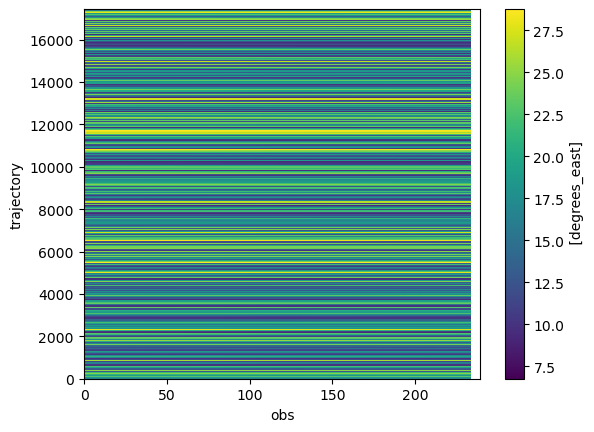

In [34]:
# Overview plot on which are alive
ds_trajectories.lon.plot()

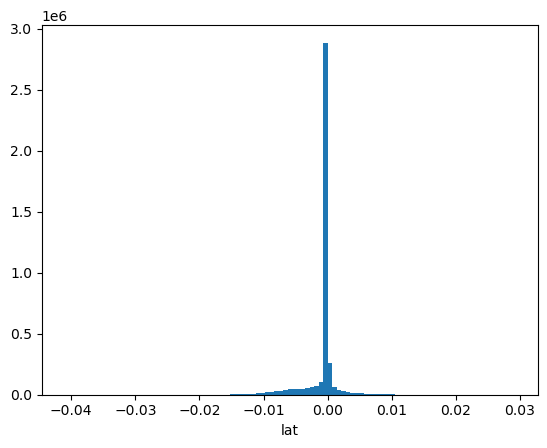

In [35]:
ds_trajectories.lat.diff("obs").plot.hist(bins=101)
plt.show()

In [36]:
print(
        "First sampled time:", ds_trajectories.time.min(skipna=True).values,
        "\nLast sampled time:", ds_trajectories.time.max(skipna=True).values,
        "\n",
        "\nFirst particle:", 
        ds_trajectories.isel(trajectory=0).time.min(skipna=True).values, "-",
        ds_trajectories.isel(trajectory=0).time.max(skipna=True).values,
        "\nLast particle:", 
        ds_trajectories.isel(trajectory=-1).time.min(skipna=True).values,"-",
        ds_trajectories.isel(trajectory=-1).time.max(skipna=True).values,
        "\n",
        "\nmaximum age in days:", max_age_days, 
        "\nfirst release date:", first_release_date, 
        "\nlast release date:", last_release_date, 
        "\nlast modeling date:", last_modeling_date,
        
)

First sampled time: 2021-01-25T06:00:00.000000000 
Last sampled time: 2021-02-03T23:00:00.000000000 
 
First particle: 2021-01-25T06:00:00.000000000 - 2021-02-03T23:00:00.000000000 
Last particle: 2021-01-25T06:00:00.000000000 - 2021-02-03T23:00:00.000000000 
 
maximum age in days: 10 
first release date: 2021-01-25 00:00:00 
last release date: 2021-01-25 00:00:00 
last modeling date: 2021-02-04 00:00:00


## Maps

In [37]:
first_lat = ds_trajectories.isel(obs=0).lat
first_lon = ds_trajectories.isel(obs=0).lon

In [38]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int)
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

last_lon = last_step.lon
last_lat = last_step.lat

last_step.to_dataframe().describe()

,age_sec,cell_ID,lat,lon,obs,time,z
count,17440.000000,17440.000000,17440.000000,17440.000000,17440.0,17440,17440.000000
mean,839700.000000,50410.710938,57.771838,17.377156,233.0,2021-02-03 23:00:00,0.500000
min,839700.000000,49699.000000,53.890732,6.762555,233.0,2021-02-03 23:00:00,0.000000
25%,839700.000000,50006.750000,55.692839,12.616582,233.0,2021-02-03 23:00:00,0.000000
50%,839700.000000,50330.000000,57.746138,17.367499,233.0,2021-02-03 23:00:00,0.500000
75%,839700.000000,50974.000000,59.587893,21.662162,233.0,2021-02-03 23:00:00,1.000000
max,839700.000000,51217.000000,63.494248,28.757844,233.0,2021-02-03 23:00:00,1.000000
std,19.065138,482.240051,2.347063,5.029668,0.0,NaN,0.500014


In [39]:
traj_dead = ds_trajectories.where(first_lon == last_lon, drop=True)
traj_moving = ds_trajectories.where(first_lon != last_lon, drop=True)

In [40]:
# open depth files and define depth cmap
depth_coarse = xr.open_dataset(path_static_coarse / "H0_file_coarse.nc").H0
depth_fine = xr.open_dataset(path_static_fine / "H0_file_fine.nc").H0
cm_deep = cmocean.cm.deep

In [41]:
traj_lat = np.concatenate(traj_moving.lat.values)
traj_lon = np.concatenate(traj_moving.lon.values)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]

In [42]:
lon_min, lon_max = (9,30)
lat_min, lat_max = (52,66)
lon_range = lon_max-lon_min
lat_range = lat_max-lat_min

In [43]:
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*4, lat_range*4), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

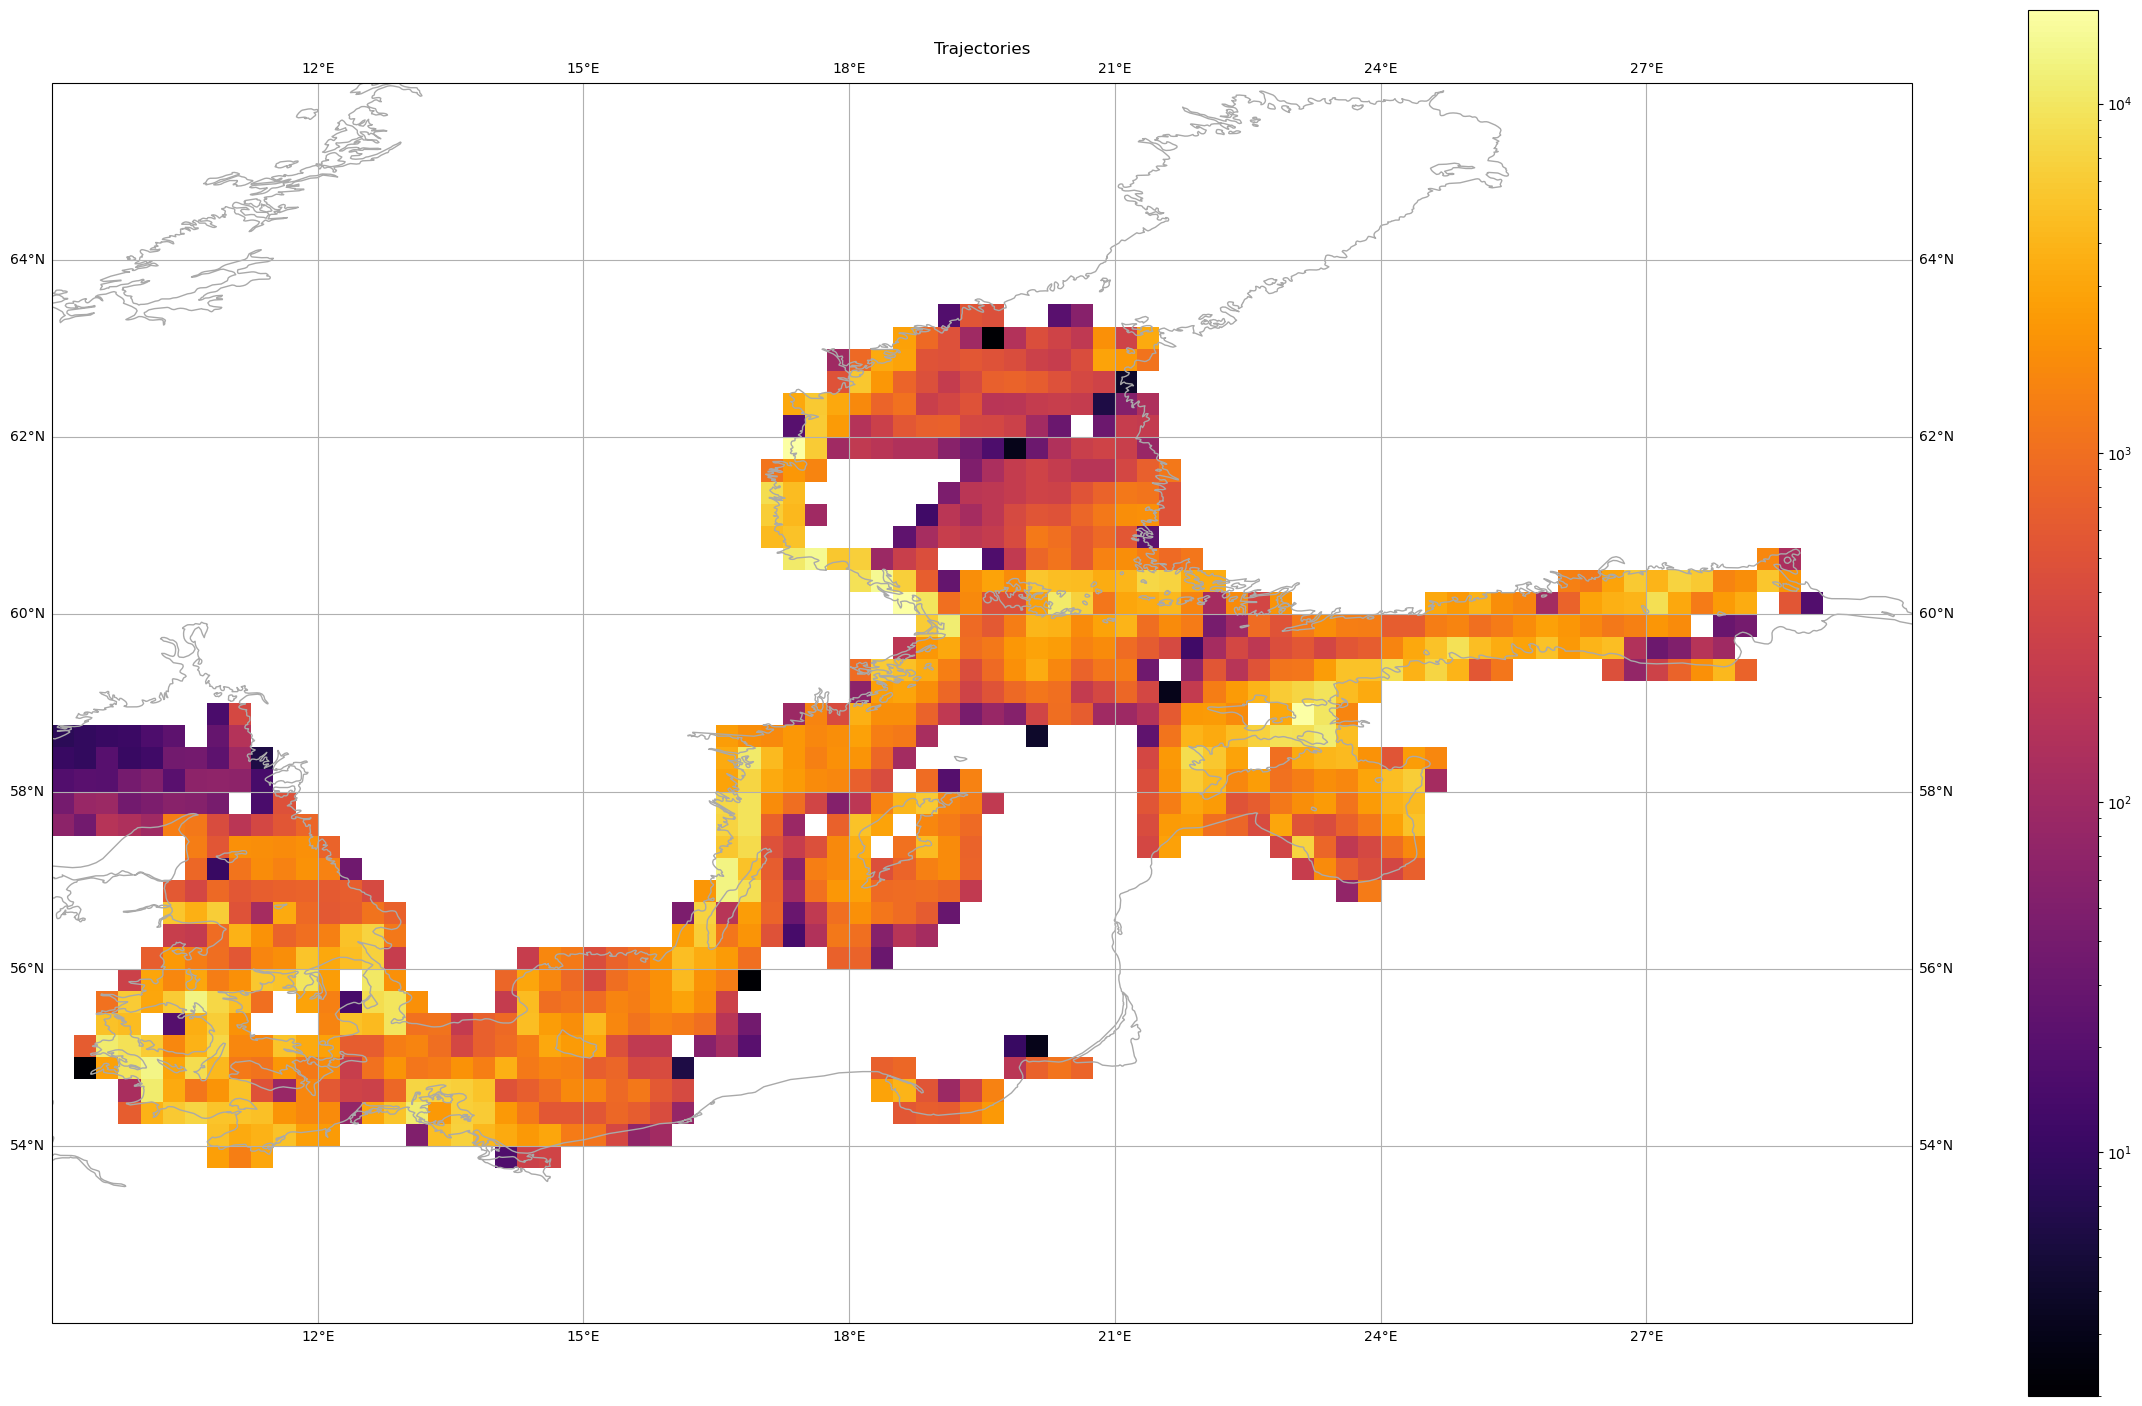

In [44]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=PlateCarree())
hm = ax.pcolormesh(xedges, yedges, hist.T, cmap="inferno", transform=PlateCarree(), norm=LogNorm())
fig.colorbar(hm)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

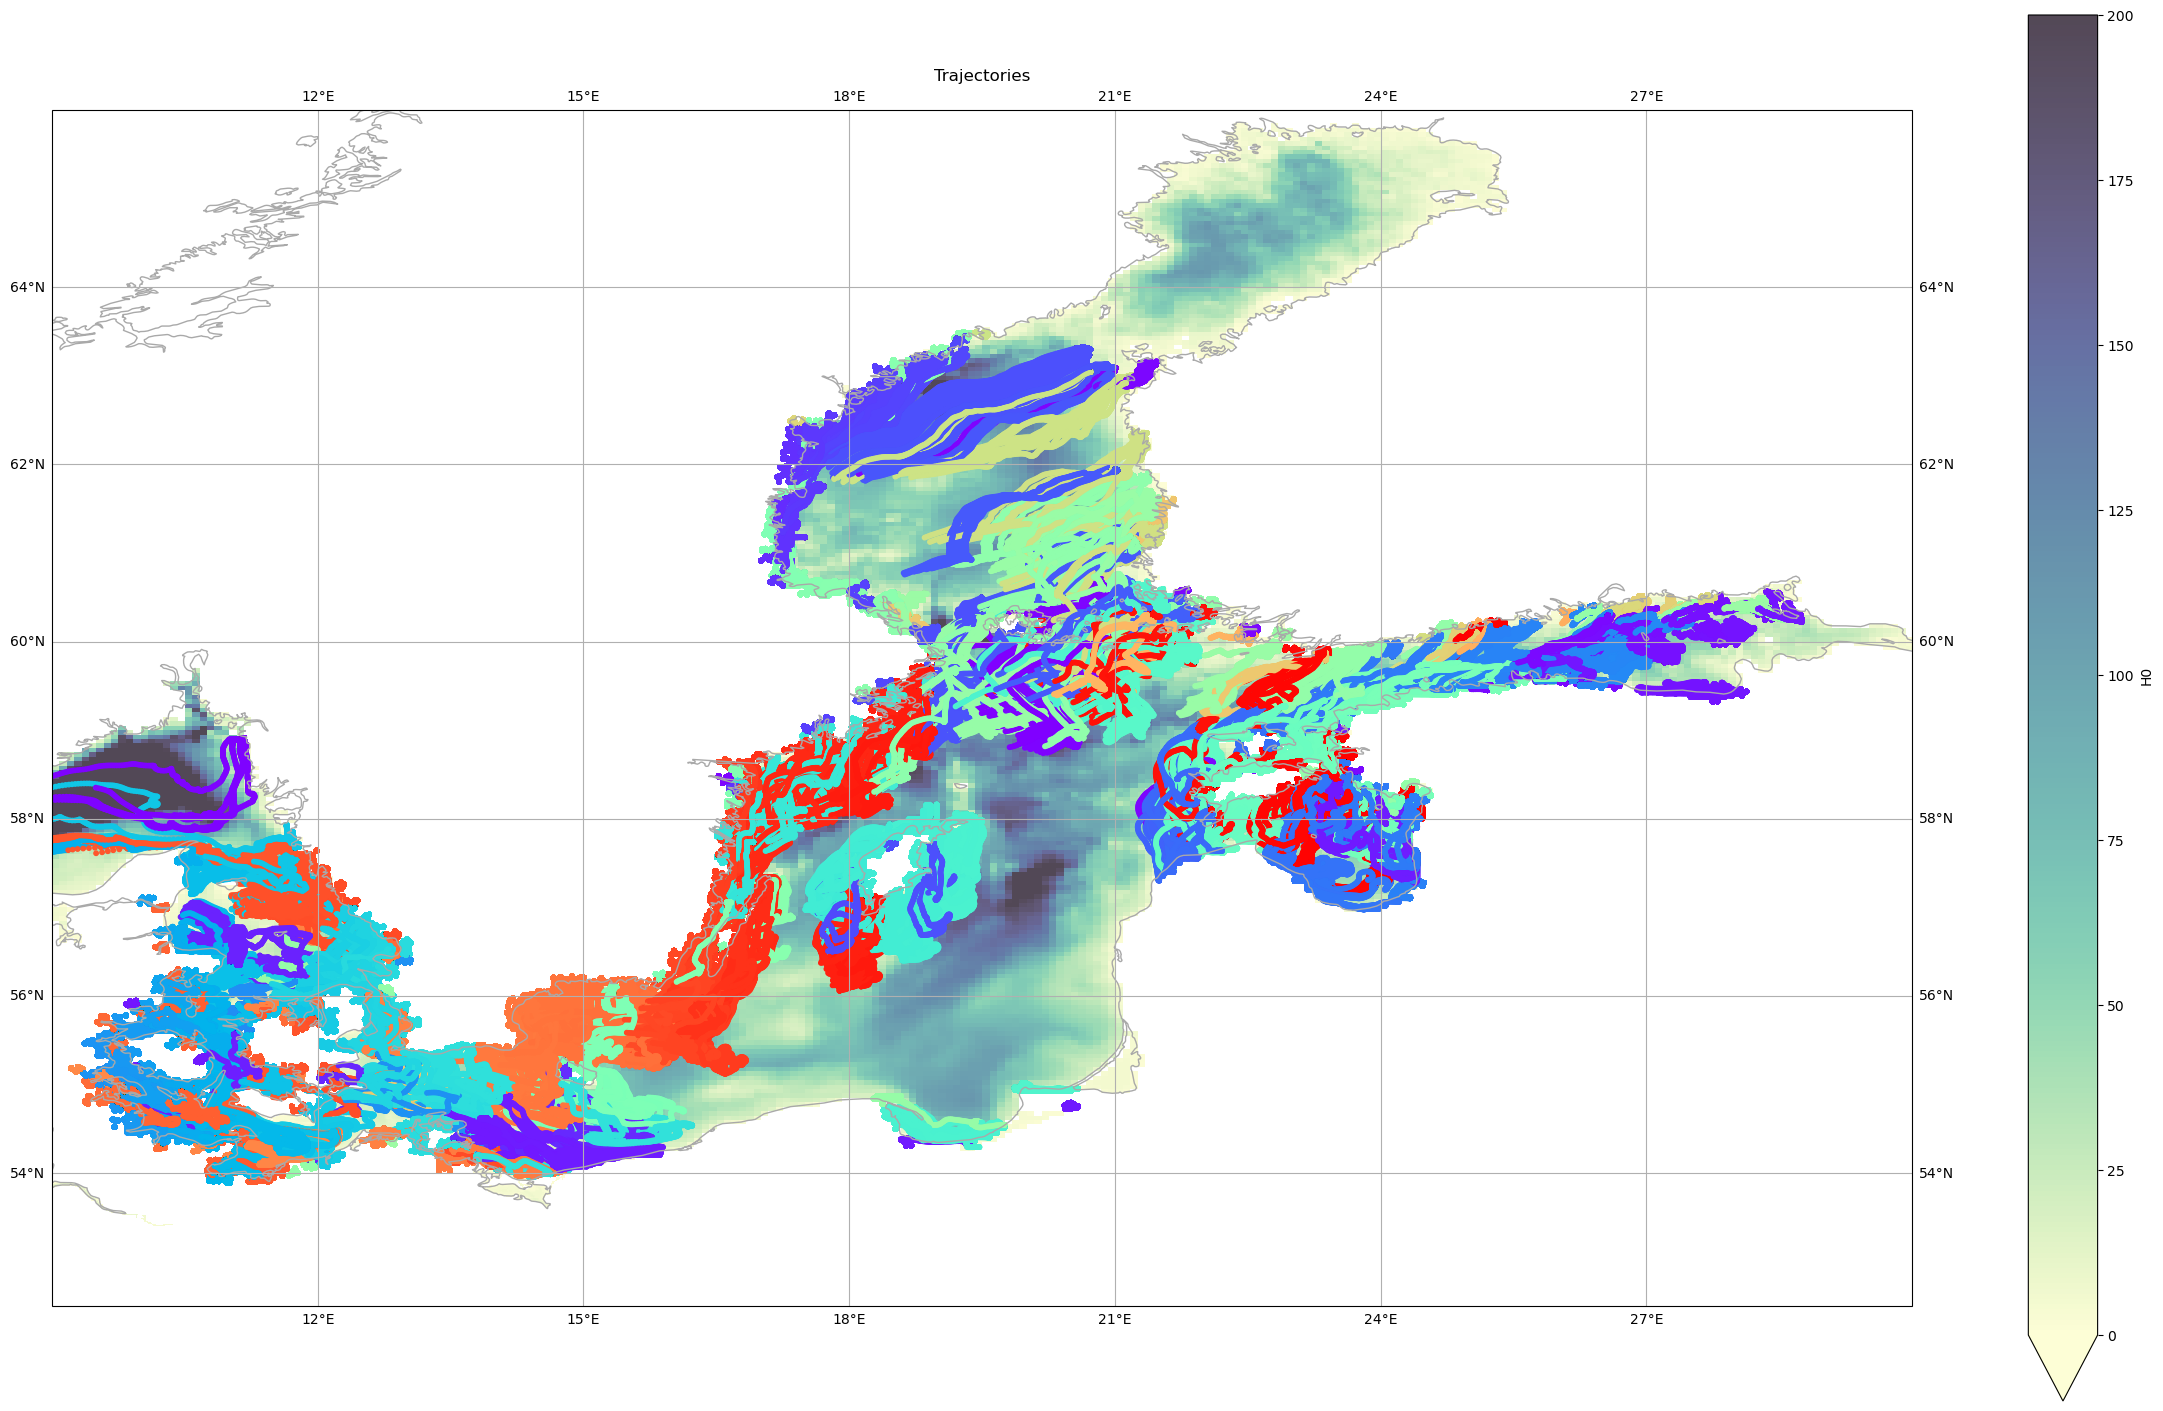

In [45]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=PlateCarree())
depth_fine.plot.imshow(cmap=cm_deep, ax=ax, vmin=0, vmax=200, alpha=.8)
depth_coarse.plot.imshow(cmap=cm_deep, ax=ax, add_colorbar=False, vmin=0, vmax=200, alpha=.8)

ax.scatter(
        x=ds_trajectories.lon, y=ds_trajectories.lat,
        c=ds_trajectories.cell_ID, cmap="rainbow",
        s=10,
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(9,30)
plt.ylim(52.5,66)
plt.show()

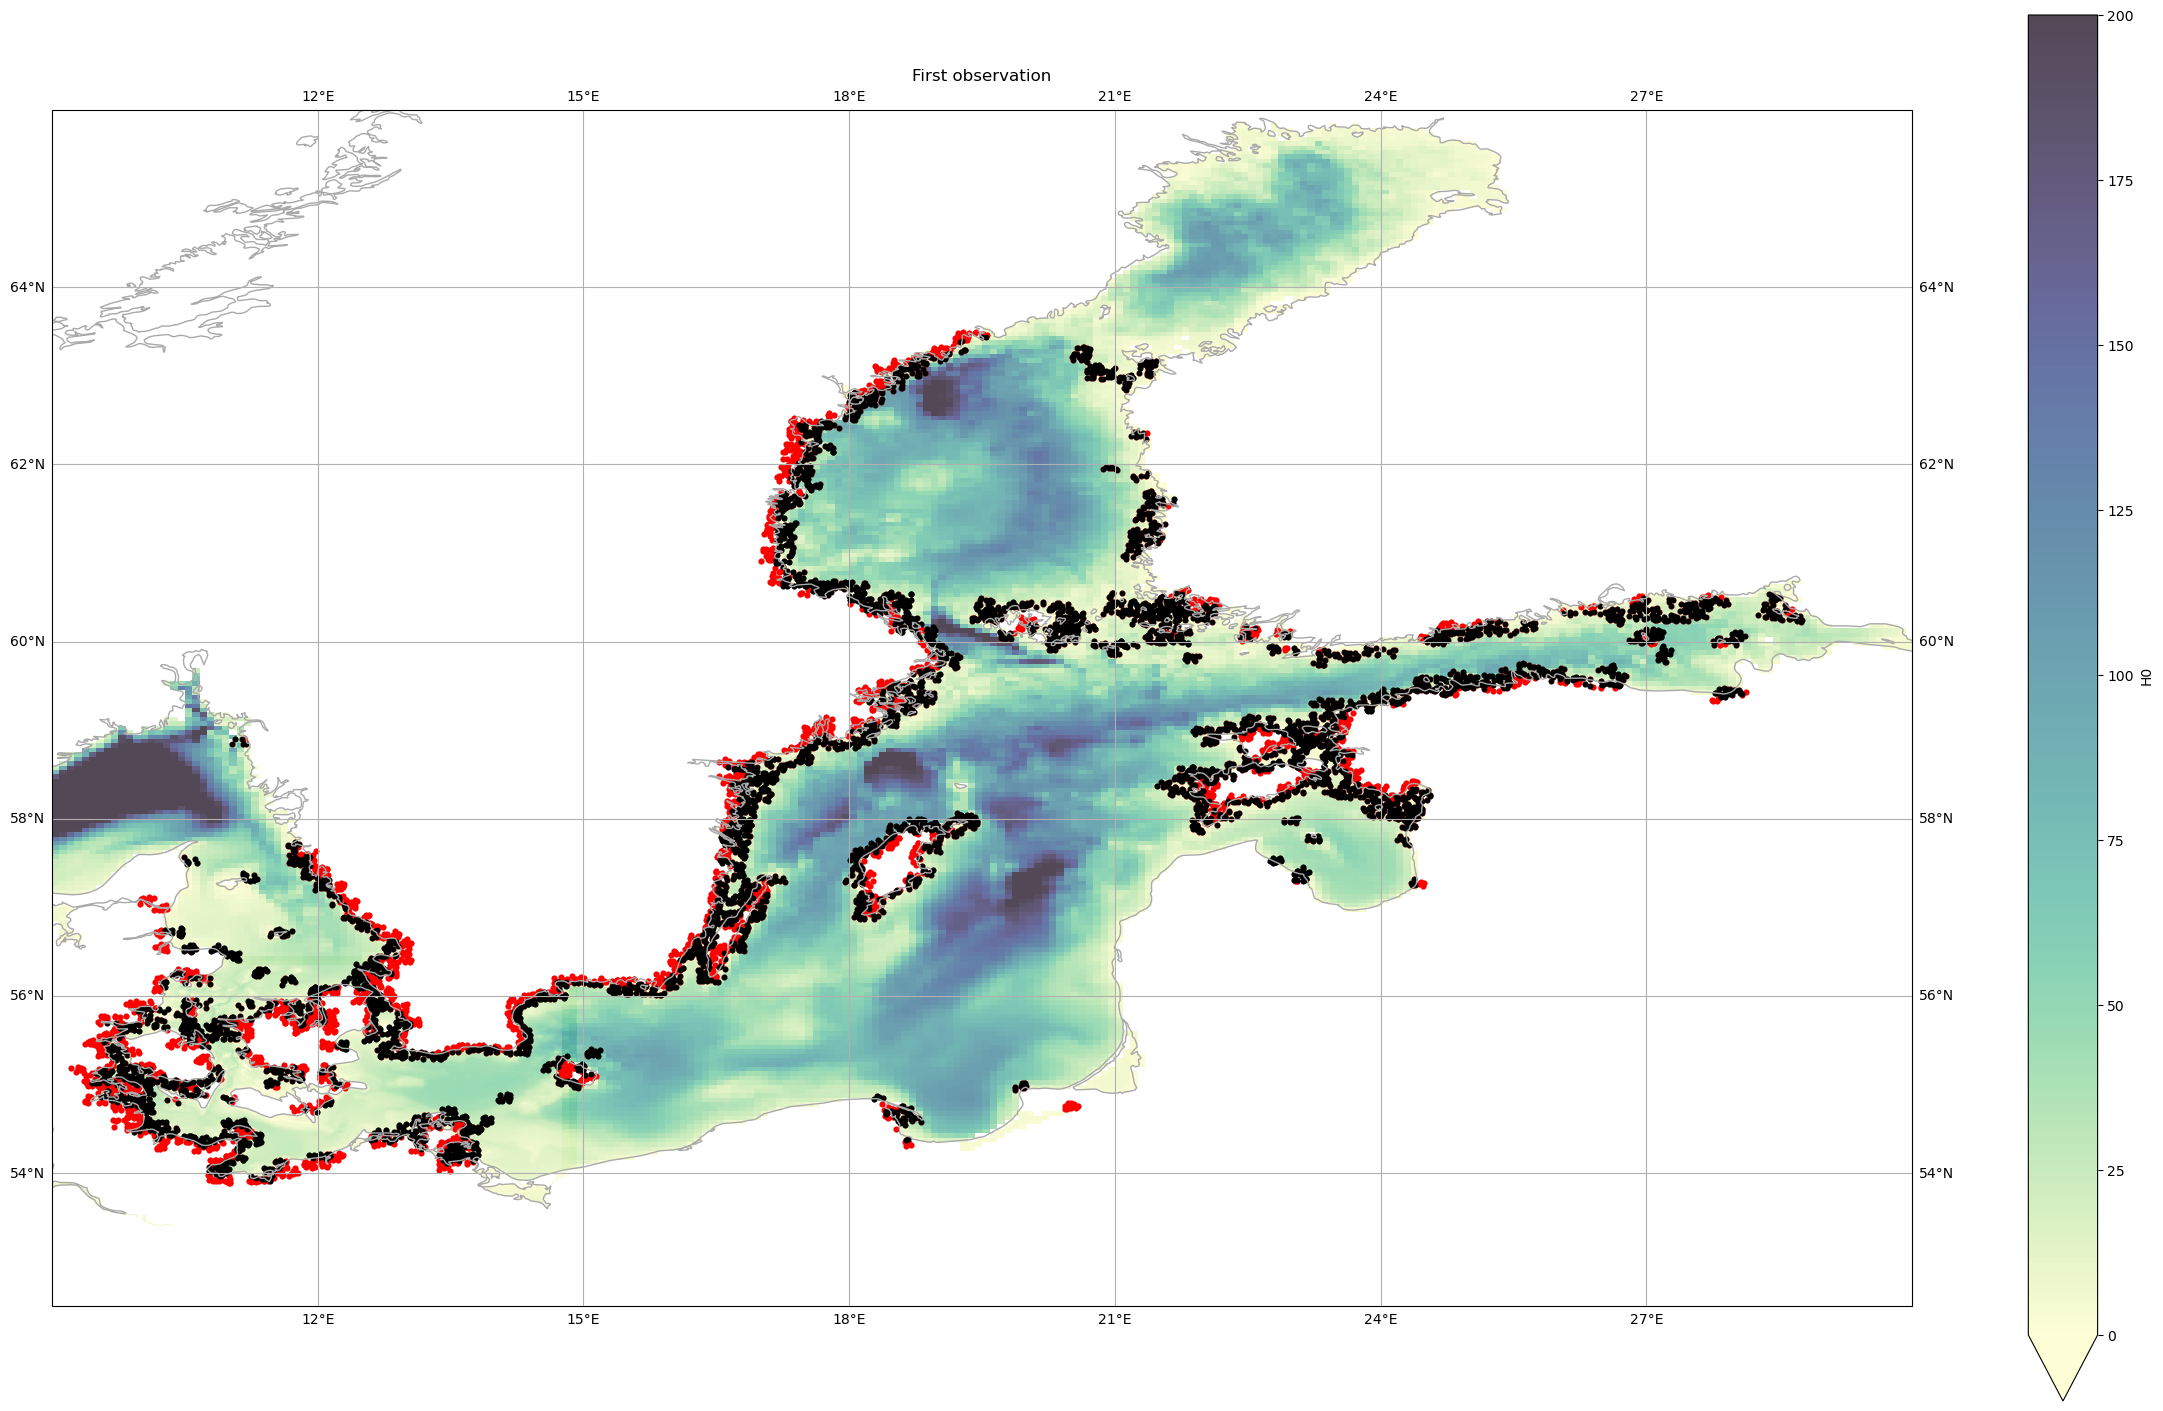

In [46]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=PlateCarree())
depth_fine.plot.imshow(cmap=cm_deep, ax=ax, vmin=0, vmax=200, alpha=.8)
depth_coarse.plot.imshow(cmap=cm_deep, ax=ax, add_colorbar=False, vmin=0, vmax=200, alpha=.8)

ax.scatter(traj_dead.isel(obs=0).lon, traj_dead.isel(obs=0).lat, c="r", s=10)
ax.scatter(traj_moving.isel(obs=0).lon, traj_moving.isel(obs=0).lat, c="k", s=10)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("First observation")
plt.xlim(9,30)
plt.ylim(52.5,66)
plt.show()

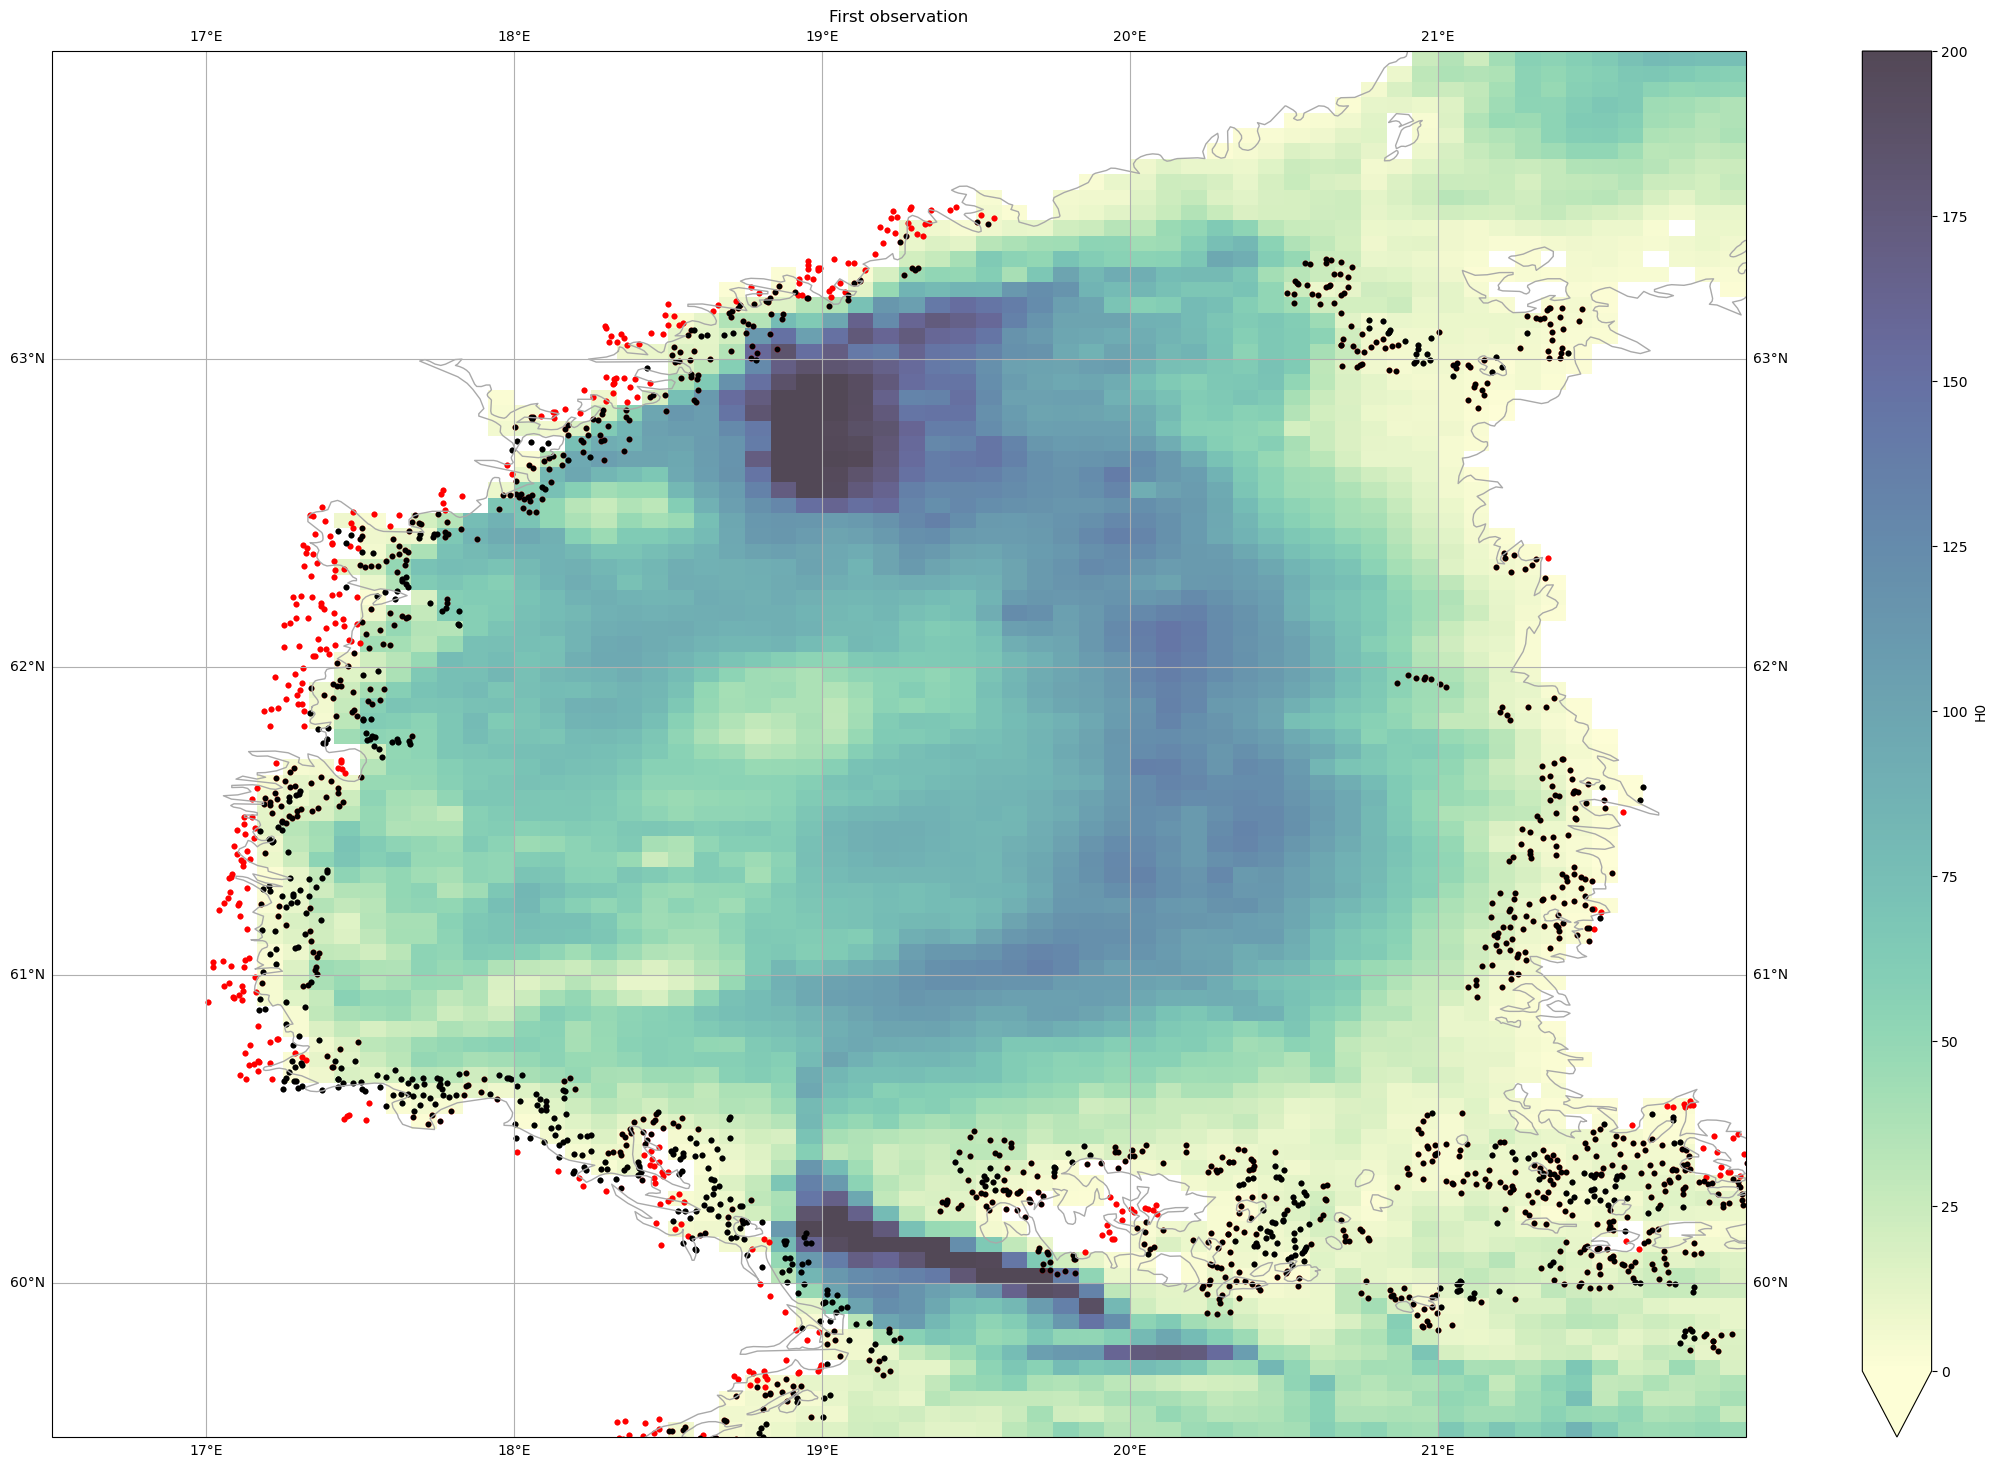

In [48]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=PlateCarree())
depth_fine.plot.imshow(cmap=cm_deep, ax=ax, vmin=0, vmax=200, alpha=.8)
depth_coarse.plot.imshow(cmap=cm_deep, ax=ax, add_colorbar=False, vmin=0, vmax=200, alpha=.8)

ax.scatter(traj_dead.isel(obs=0).lon, traj_dead.isel(obs=0).lat, c="r", s=10)
ax.scatter(traj_moving.isel(obs=0).lon, traj_moving.isel(obs=0).lat, c="k", s=10)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("First observation")
plt.xlim(16.5,22)
plt.ylim(59.5,64)
plt.show()

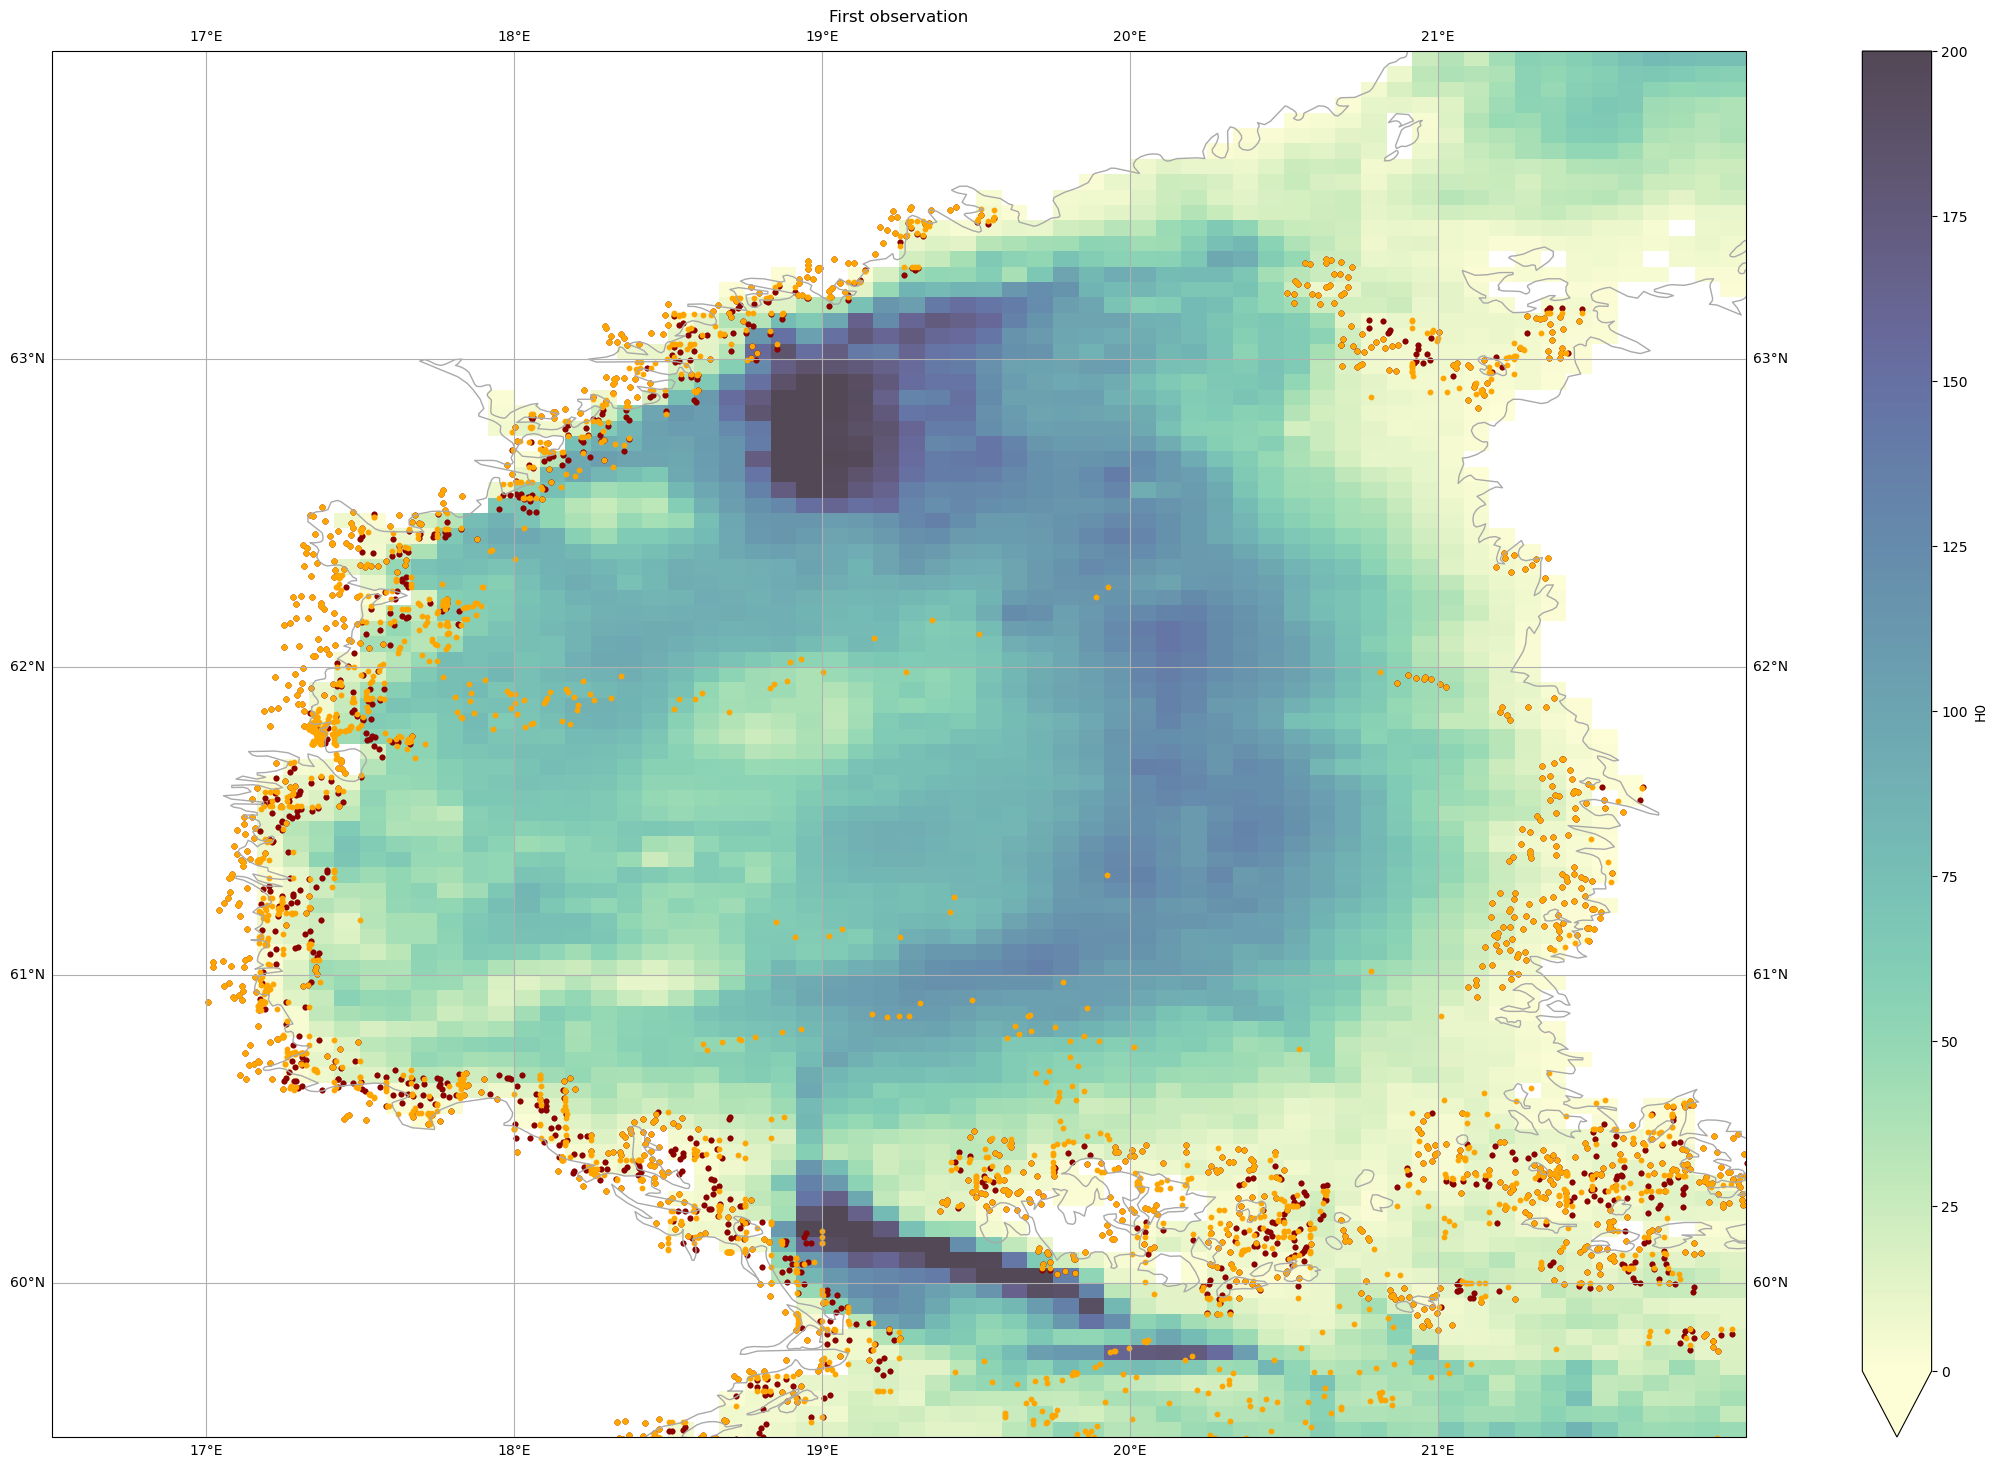

In [49]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=PlateCarree())
depth_fine.plot.imshow(cmap=cm_deep, ax=ax, vmin=0, vmax=200, alpha=.8)
depth_coarse.plot.imshow(cmap=cm_deep, ax=ax, add_colorbar=False, vmin=0, vmax=200, alpha=.8)

ax.scatter(first_lon, first_lat, c="darkred", s=10)
ax.scatter(last_lon, last_lat, c="orange", s=10)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("First observation")
plt.xlim(16.5,22)
plt.ylim(59.5,64)
plt.show()

In [50]:
ganz_tot = np.unique(traj_dead.isel(obs=0).cell_ID.values)[
        np.invert(
                np.in1d(
                        np.unique(traj_dead.isel(obs=0).cell_ID.values),
                        np.unique(traj_moving.isel(obs=0).cell_ID.values)
                )
        )
]
len(ganz_tot)

70